# Проверка статистических гипотез

## Модуль 3: p-значения, t-тесты, ANOVA, хи-квадрат тесты

В этом ноутбуке мы рассмотрим основные методы проверки статистических гипотез.

### Содержание:
1. Нулевая и альтернативная гипотезы
2. p-значение и ошибки I и II рода
3. Одновыборочный t-тест
4. Двухвыборочный t-тест
5. Парный t-тест
6. Дисперсионный анализ (ANOVA)
7. Хи-квадрат тест

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Нулевая и альтернативная гипотезы

**Нулевая гипотеза ($H_0$):** Утверждение, которое мы проверяем (обычно "нет эффекта").

**Альтернативная гипотеза ($H_1$ или $H_a$):** Утверждение, которое мы хотим доказать.

### Типы альтернативных гипотез:
- **Двусторонняя:** $H_1: \mu \neq \mu_0$
- **Левосторонняя:** $H_1: \mu < \mu_0$
- **Правосторонняя:** $H_1: \mu > \mu_0$

### Примеры:
- $H_0: \mu = 100$ vs $H_1: \mu \neq 100$ (IQ студентов)
- $H_0: p = 0.5$ vs $H_1: p > 0.5$ (эффективность лекарства)
- $H_0: \mu_1 = \mu_2$ vs $H_1: \mu_1 \neq \mu_2$ (сравнение групп)

## 2. p-значение и ошибки

**p-значение** — вероятность получить такие же или более экстремальные результаты при условии, что $H_0$ истинна.

$$p\text{-value} = P(\text{данные} | H_0)$$

**Правило решения:**
- Если $p < \alpha$ (уровень значимости), отвергаем $H_0$
- Если $p \geq \alpha$, не отвергаем $H_0$

### Ошибки:

| | $H_0$ истинна | $H_0$ ложна |
|---|---|---|
| **Не отвергли $H_0$** | Верно | Ошибка II рода ($\beta$) |
| **Отвергли $H_0$** | Ошибка I рода ($\alpha$) | Верно (мощность $1-\beta$) |

- **Ошибка I рода ($\alpha$):** Отклонить верную $H_0$ (ложноположительный результат)
- **Ошибка II рода ($\beta$):** Не отклонить ложную $H_0$ (ложноотрицательный результат)
- **Мощность ($1-\beta$):** Вероятность correctly отклонить ложную $H_0$

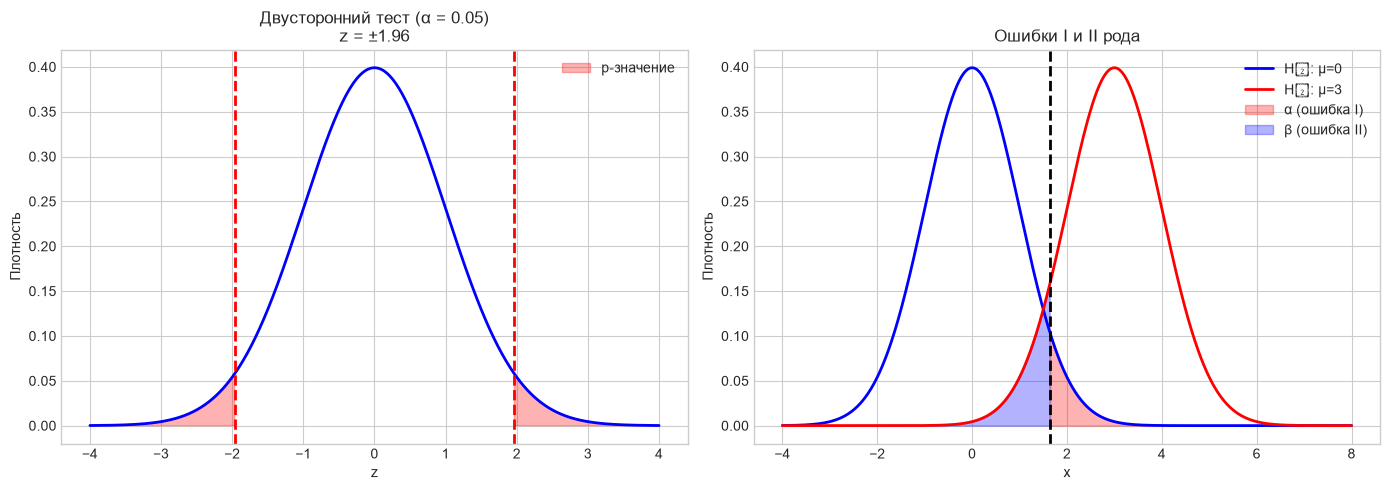

In [3]:
# Визуализация: p-значение и распределение
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Двусторонний тест
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

axes[0].plot(x, y, 'b-', linewidth=2)
axes[0].fill_between(x, y, where=(x <= -1.96) | (x >= 1.96), 
                     alpha=0.3, color='red', label='p-значение')
axes[0].axvline(-1.96, color='red', linestyle='--', linewidth=2)
axes[0].axvline(1.96, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('z')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Двусторонний тест (α = 0.05)\nz = ±1.96')
axes[0].legend()

# Ошибки I и II рода
x = np.linspace(-4, 8, 1000)
y_h0 = stats.norm.pdf(x, 0, 1)
y_h1 = stats.norm.pdf(x, 3, 1)

axes[1].plot(x, y_h0, 'b-', linewidth=2, label='H₀: μ=0')
axes[1].plot(x, y_h1, 'r-', linewidth=2, label='H₁: μ=3')
axes[1].fill_between(x, y_h0, where=x >= 1.645, alpha=0.3, color='red', label='α (ошибка I)')
axes[1].fill_between(x, y_h1, where=x < 1.645, alpha=0.3, color='blue', label='β (ошибка II)')
axes[1].axvline(1.645, color='black', linestyle='--', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Ошибки I и II рода')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Одновыборочный t-тест

**Задача:** Проверить, отличается ли среднее генеральной совокупности от заданного значения.

$$H_0: \mu = \mu_0$$
$$H_1: \mu \neq \mu_0$$

**t-статистика:**
$$t = \frac{\bar{X} - \mu_0}{s / \sqrt{n}} \sim t(n-1)$$

**Условия применения:**
- Данные approximately нормально распределены
- Наблюдения независимы
- $n \geq 30$ (для ЦПТ)

Одновыборочный t-тест
H₀: μ = 100
H₁: μ ≠ 100 (двусторонний тест)

Данные: n = 20, X̄ = 105.65, s = 5.37

t-статистика: 4.7025
p-значение: 0.0002

α = 0.05
Решение: Отвергаем H₀


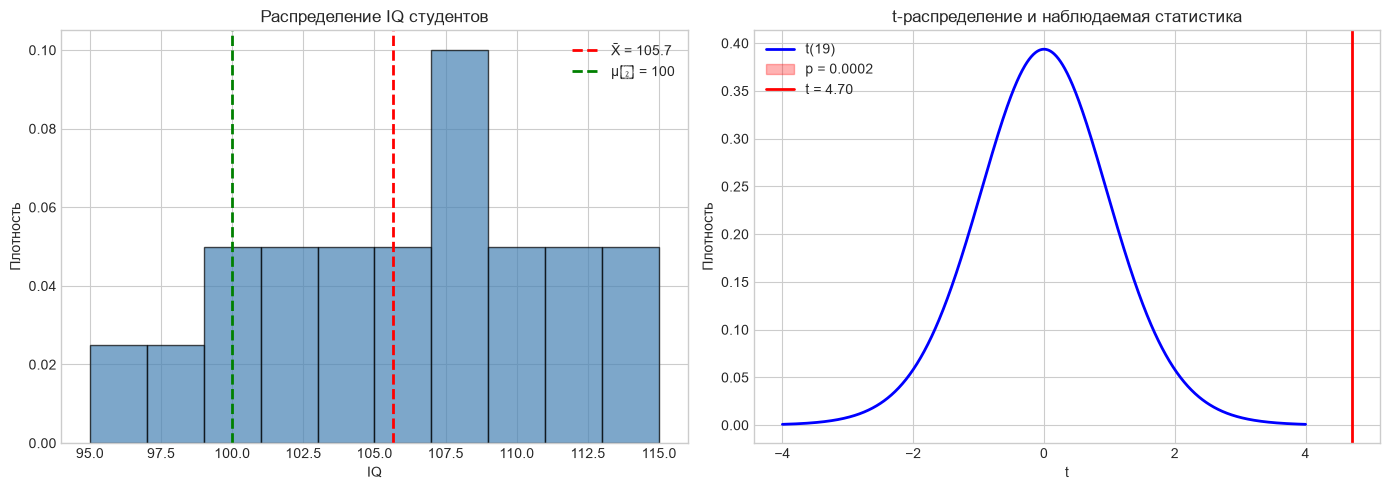

In [4]:
# Пример: Одновыборочный t-тест
np.random.seed(42)

# Данные: IQ студентов (предполагаем, что среднее IQ = 100)
iq_scores = np.array([105, 110, 98, 112, 108, 95, 115, 102, 107, 103,
                       99, 111, 106, 104, 109, 101, 113, 107, 100, 108])

n = len(iq_scores)
x_bar = np.mean(iq_scores)
s = np.std(iq_scores, ddof=1)
mu_0 = 100  # Гипотетическое среднее

# t-тест
t_stat, p_value = stats.ttest_1samp(iq_scores, mu_0)

alpha = 0.05

print('Одновыборочный t-тест')
print('=' * 60)
print(f'H₀: μ = {mu_0}')
print(f'H₁: μ ≠ {mu_0} (двусторонний тест)')
print(f'\nДанные: n = {n}, X̄ = {x_bar:.2f}, s = {s:.2f}')
print(f'\nt-статистика: {t_stat:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение данных
axes[0].hist(iq_scores, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(x_bar, color='red', linestyle='--', linewidth=2, label=f'X̄ = {x_bar:.1f}')
axes[0].axvline(mu_0, color='green', linestyle='--', linewidth=2, label=f'μ₀ = {mu_0}')
axes[0].set_xlabel('IQ')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение IQ студентов')
axes[0].legend()

# t-распределение
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, n-1)
axes[1].plot(x, y, 'b-', linewidth=2, label=f't({n-1})')
axes[1].fill_between(x, y, where=(x <= -abs(t_stat)) | (x >= abs(t_stat)), 
                     alpha=0.3, color='red', label=f'p = {p_value:.4f}')
axes[1].axvline(t_stat, color='red', linestyle='-', linewidth=2, 
                label=f't = {t_stat:.2f}')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Плотность')
axes[1].set_title('t-распределение и наблюдаемая статистика')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Двухвыборочный t-тест

**Задача:** Сравнить средние двух независимых групп.

$$H_0: \mu_1 = \mu_2$$
$$H_1: \mu_1 \neq \mu_2$$

**t-статистика (Welch's t-test):**
$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

**Степени свободы (аппроксимация Уэлча):**
$$\nu = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1} + \frac{(s_2^2/n_2)^2}{n_2-1}}$$

Двухвыборочный t-тест (Welch)
H₀: μ_A = μ_B
H₁: μ_A ≠ μ_B (двусторонний тест)

Метод A: n = 20, X̄ = 86.00, s = 3.61
Метод B: n = 20, X̄ = 77.65, s = 3.41

t-статистика: 7.5197
p-значение: 0.0000

α = 0.05
Решение: Отвергаем H₀


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

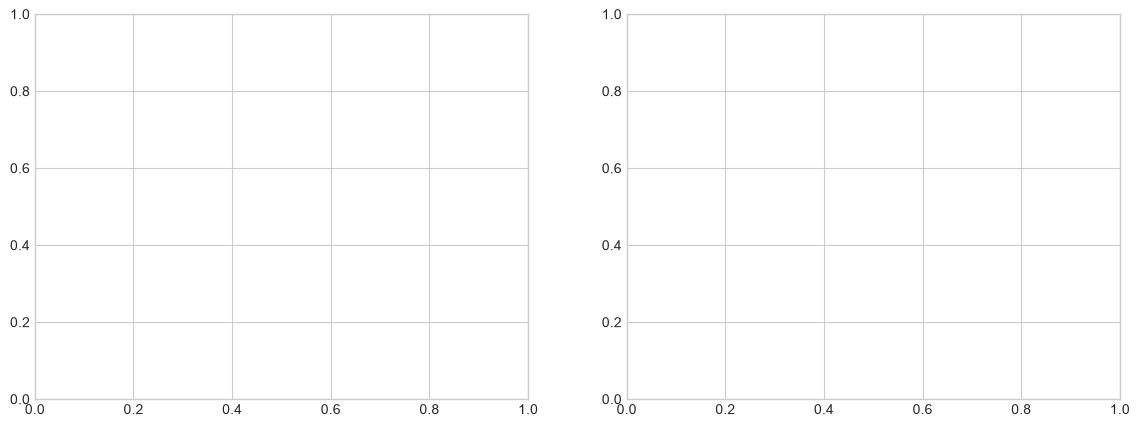

In [5]:
# Пример: Двухвыборочный t-тест
np.random.seed(42)

# Данные: Эффективность двух методов обучения
method_a = np.array([78, 82, 85, 88, 90, 84, 86, 89, 91, 87,
                     83, 80, 85, 88, 92, 86, 84, 87, 90, 85])
method_b = np.array([72, 75, 78, 80, 82, 76, 79, 81, 83, 77,
                     74, 71, 76, 79, 83, 77, 75, 78, 81, 76])

# t-тест (Welch)
t_stat, p_value = stats.ttest_ind(method_a, method_b, equal_var=False)

alpha = 0.05

print('Двухвыборочный t-тест (Welch)')
print('=' * 60)
print(f'H₀: μ_A = μ_B')
print(f'H₁: μ_A ≠ μ_B (двусторонний тест)')
print(f'\nМетод A: n = {len(method_a)}, X̄ = {np.mean(method_a):.2f}, s = {np.std(method_a, ddof=1):.2f}')
print(f'Метод B: n = {len(method_b)}, X̄ = {np.mean(method_b):.2f}, s = {np.std(method_b, ddof=1):.2f}')
print(f'\nt-статистика: {t_stat:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [method_a, method_b]
bp = axes[0].boxplot(data_to_plot, labels=['Метод A', 'Метод B'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
axes[0].set_ylabel('Баллы')
axes[0].set_title('Сравнение методов обучения')

# Добавим средние
axes[0].scatter([1, 2], [np.mean(method_a), np.mean(method_b)], 
                color='red', marker='D', s=100, zorder=5, label='Средние')
axes[0].legend()

# Распределения
x_range = np.linspace(65, 100, 1000)
axes[1].plot(x_range, stats.norm.pdf(x_range, np.mean(method_a), np.std(method_a, ddof=1)), 
             'b-', linewidth=2, label=f'Метод A (μ={np.mean(method_a):.1f})')
axes[1].plot(x_range, stats.norm.pdf(x_range, np.mean(method_b), np.std(method_b, ddof=1)), 
             'r-', linewidth=2, label=f'Метод B (μ={np.mean(method_b):.1f})')
axes[1].set_xlabel('Баллы')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределения баллов')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Парный t-тест

**Задача:** Сравнить средние двух зависимых групп (до и после воздействия).

$$H_0: \mu_D = 0$$
$$H_1: \mu_D \neq 0$$

где $D_i = X_{1i} - X_{2i}$ — разности для парных наблюдений.

**t-статистика:**
$$t = \frac{\bar{D}}{s_D / \sqrt{n}} \sim t(n-1)$$

In [ ]:
# Пример: Парный t-тест
np.random.seed(42)

# Данные: Вес до и после диеты
n_subjects = 15
weight_before = np.random.normal(85, 10, n_subjects)
weight_after = weight_before - np.random.normal(3, 2, n_subjects)  # Снижение веса

# Разности
differences = weight_before - weight_after

# Парный t-тест
t_stat, p_value = stats.ttest_rel(weight_before, weight_after)

alpha = 0.05

print('Парный t-тест')
print('=' * 60)
print(f'H₀: μ_D = 0 (нет эффекта диеты)')
print(f'H₁: μ_D ≠ 0')
print(f'\nДанные: n = {n_subjects}')
print(f'Средний вес до: {np.mean(weight_before):.2f} кг')
print(f'Средний вес после: {np.mean(weight_after):.2f} кг')
print(f'Средняя разность: {np.mean(differences):.2f} кг')
print(f'\nt-статистика: {t_stat:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# До и после
axes[0].scatter(range(n_subjects), weight_before, color='blue', 
                marker='o', label='До', s=50)
axes[0].scatter(range(n_subjects), weight_after, color='red', 
                marker='s', label='После', s=50)
for i in range(n_subjects):
    axes[0].plot([i, i], [weight_before[i], weight_after[i]], 
                 'gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Субъект')
axes[0].set_ylabel('Вес (кг)')
axes[0].set_title('Вес до и после диеты')
axes[0].legend()

# Разности
axes[1].bar(range(n_subjects), differences, color='green', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].axhline(y=np.mean(differences), color='blue', linestyle='-', linewidth=2, 
                label=f'Среднее = {np.mean(differences):.2f}')
axes[1].set_xlabel('Субъект')
axes[1].set_ylabel('Разность (кг)')
axes[1].set_title('Изменение веса')
axes[1].legend()

# Распределение разностей
axes[2].hist(differences, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='H₀: μ_D = 0')
axes[2].axvline(np.mean(differences), color='green', linestyle='-', linewidth=2, 
                label=f'X̄_D = {np.mean(differences):.2f}')
axes[2].set_xlabel('Разность (кг)')
axes[2].set_ylabel('Плотность')
axes[2].set_title('Распределение разностей')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Дисперсионный анализ (ANOVA)

**Задача:** Сравнить средние трёх и более групп.

$$H_0: \mu_1 = \mu_2 = ... = \mu_k$$
$$H_1: \text{Хотя бы одно среднее отличается}$$

**F-статистика:**
$$F = \frac{\text{Межгрупповая дисперсия}}{\text{Внутригрупповая дисперсия}} = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$

где:
$$MS_{\text{between}} = \frac{SS_{\text{between}}}{k-1}, \quad MS_{\text{within}} = \frac{SS_{\text{within}}}{N-k}$$

**Условия применения:**
- Независимость наблюдений
- Нормальность данных в каждой группе
- Гомогенность дисперсий (гомоскедастичность)

In [ ]:
# Пример: ANOVA
np.random.seed(42)

# Данные: Эффективность трёх препаратов
n_per_group = 20
drug_a = np.random.normal(50, 10, n_per_group)
drug_b = np.random.normal(55, 10, n_per_group)
drug_c = np.random.normal(60, 10, n_per_group)

# ANOVA
f_stat, p_value = stats.f_oneway(drug_a, drug_b, drug_c)

alpha = 0.05

print('Однофакторный ANOVA')
print('=' * 60)
print(f'H₀: μ_A = μ_B = μ_C')
print(f'H₁: Хотя бы одно среднее отличается')
print(f'\nПрепарат A: n = {len(drug_a)}, X̄ = {np.mean(drug_a):.2f}, s = {np.std(drug_a, ddof=1):.2f}')
print(f'Препарат B: n = {len(drug_b)}, X̄ = {np.mean(drug_b):.2f}, s = {np.std(drug_b, ddof=1):.2f}')
print(f'Препарат C: n = {len(drug_c)}, X̄ = {np.mean(drug_c):.2f}, s = {np.std(drug_c, ddof=1):.2f}')
print(f'\nF-статистика: {f_stat:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [drug_a, drug_b, drug_c]
bp = axes[0].boxplot(data_to_plot, labels=['Препарат A', 'Препарат B', 'Препарат C'], 
                     patch_artist=True)
colors = ['lightblue', 'lightcoral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_ylabel('Эффективность')
axes[0].set_title('Сравнение препаратов')

# Добавим средние
means = [np.mean(drug_a), np.mean(drug_b), np.mean(drug_c)]
axes[0].scatter([1, 2, 3], means, color='red', marker='D', s=100, zorder=5)

# F-распределение
df_between = 3 - 1
df_within = len(drug_a) + len(drug_b) + len(drug_c) - 3
x = np.linspace(0, 8, 1000)
y = stats.f.pdf(x, df_between, df_within)
axes[1].plot(x, y, 'b-', linewidth=2, label=f'F({df_between}, {df_within})')
axes[1].fill_between(x, y, where=x >= f_stat, alpha=0.3, color='red', 
                     label=f'p = {p_value:.4f}')
axes[1].axvline(f_stat, color='red', linestyle='-', linewidth=2, 
                label=f'F = {f_stat:.2f}')
axes[1].set_xlabel('F')
axes[1].set_ylabel('Плотность')
axes[1].set_title('F-распределение')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Хи-квадрат тест

### 7.1 Хи-квадрат тест на согласие (Goodness of Fit)

**Задача:** Проверить, соответствуют ли наблюдаемые частоты ожидаемым.

$$H_0: \text{Данные следуют теоретическому распределению}$$
$$H_1: \text{Данные НЕ следуют теоретическому распределению}$$

**Статистика:**
$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

### 7.2 Хи-квадрат тест на независимость

**Задача:** Проверить, есть ли связь между двумя категориальными переменными.

$$H_0: \text{Переменные независимы}$$
$$H_1: \text{Переменные зависимы}$$

In [ ]:
# Пример 1: Хи-квадрат тест на согласие
np.random.seed(42)

# Данные: Частоты выпадения граней кубика
observed = np.array([18, 15, 22, 17, 14, 14])  # Наблюдаемые частоты
expected = np.array([16.67, 16.67, 16.67, 16.67, 16.67, 16.67])  # Ожидаемые (честный кубик)

# Хи-квадрат тест
chi2_stat, p_value = stats.chisquare(observed, expected)

alpha = 0.05

print('Хи-квадрат тест на согласие')
print('=' * 60)
print('H₀: Кубик честный (все грани равновероятны)')
print('H₁: Кубик нечестный')
print(f'\nНаблюдаемые частоты: {observed}')
print(f'Ожидаемые частоты: {expected.round(2)}')
print(f'\nχ² статистика: {chi2_stat:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

print('\n' + '='*60)

# Пример 2: Хи-квадрат тест на независимость
# Данные: Пол и предпочтение цвета
data = np.array([[20, 30, 50],  # Мужчины
                 [40, 35, 25]])  # Женщины

chi2_stat, p_value, dof, expected = stats.chi2_contingency(data)

print('Хи-квадрат тест на независимость')
print('=' * 60)
print('H₀: Пол и предпочтение цвета независимы')
print('H₁: Пол и предпочтение цвета зависимы')
print(f'\nНаблюдаемые частоты:')
print(data)
print(f'\nОжидаемые частоты:')
print(expected.round(2))
print(f'\nχ² статистика: {chi2_stat:.4f}')
print(f'Степени свободы: {dof}')
print(f'p-значение: {p_value:.4f}')
print(f'\nα = {alpha}')
print(f'Решение: {"Отвергаем H₀" if p_value < alpha else "Не отвергаем H₀"}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Тест на согласие
x = np.arange(1, 7)
width = 0.35
axes[0].bar(x - width/2, observed, width, label='Наблюдаемые', color='steelblue', alpha=0.7)
axes[0].bar(x + width/2, expected, width, label='Ожидаемые', color='coral', alpha=0.7)
axes[0].set_xlabel('Грань кубика')
axes[0].set_ylabel('Частота')
axes[0].set_title('Тест на согласие')
axes[0].legend()

# Тест на независимость
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, data[0], width, label='Мужчины', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, data[1], width, label='Женщины', color='coral', alpha=0.7)
axes[1].set_xlabel('Цвет')
axes[1].set_ylabel('Количество')
axes[1].set_title('Предпочтение цвета по полу')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Красный', 'Синий', 'Зелёный'])
axes[1].legend()

plt.tight_layout()
plt.show()

## Упражнения

### Упражнение 1: Одновыборочный t-тест
Фабрика утверждает, что их продукция весит 500 г. Вы взяли 25 образцов:
```
[498, 502, 501, 499, 503, 500, 497, 504, 502, 498,
 501, 500, 499, 503, 502, 498, 501, 500, 499, 503,
 502, 498, 501, 500, 499]
```

1. Проверьте гипотезу на уровне значимости 0.05
2. Каков p-value?

### Упражнение 2: Двухвыборочный t-тест
Сравните эффективность двух рекламных кампаний:
- Кампания A: конверсия [12, 15, 18, 14, 16, 19, 13, 17, 15, 16]
- Кампания B: конверсия [10, 12, 14, 11, 13, 15, 12, 14, 13, 11]

1. Есть ли статистически значимая разница?
2. Какова мощность теста?

### Упражнение 3: ANOVA
Три группы студентов учились разными методами:
- Метод 1: [85, 88, 90, 82, 87]
- Метод 2: [78, 82, 80, 76, 79]
- Метод 3: [92, 95, 88, 90, 93]

1. Проведите ANOVA
2. Какой метод наиболее эффективен?

### Упражнение 4: Хи-квадрат тест
Данные о заболеваемости по сезонам:
- Зима: 120
- Весна: 80
- Лето: 60
- Осень: 140

1. Проверьте, одинакова ли заболеваемость во все сезоны
2. Какой сезон имеет наибольшую заболеваемость?

---

**Решения** можно найти в ноутбуке `solutions/08_Solutions.ipynb`